## Path Configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.config import load_config
from utils.data import load_pkl
from utils.style_transfer import style_transfer

## Data loading

In [5]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [6]:
driams = load_pkl(driams_pkl)

In [7]:
data, label, meta = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))

In [8]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

In [9]:
# Filter the data by hospital
filtered_data = {}
for hosp in meta["hospital"].unique():
    idx = np.where(meta["hospital"].values == hosp)[0]
    filtered_data[hosp] = {
        "data": data_norm[idx],
        "label": label[idx],
        "meta": meta.iloc[idx]
    }

In [10]:
# Declare the datasets
dataA, labelA, metaA = filtered_data["DRIAMS_A"]["data"], filtered_data["DRIAMS_A"]["label"], filtered_data["DRIAMS_A"]["meta"]
dataD, labelD, metaD = filtered_data["DRIAMS_D"]["data"], filtered_data["DRIAMS_D"]["label"], filtered_data["DRIAMS_D"]["meta"]

## Style transfer

#### Utils

In [11]:
import torch
from models.deep.MultiVAEPrior import MultiVAE_Bernoulli_SpeciesPrior_Extended

In [12]:
def load_model(model, path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

def encode_latent(model, X, device, batch_size=256):
    model.eval()
    Z = []

    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = torch.utils.data.DataLoader(
        X_tensor,
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            mu, _ = model.encoder(x)
            Z.append(mu.cpu().numpy())

    return np.vstack(Z)

#### Load MultiDecoder

In [13]:
meta_all = pd.concat([metaA, metaD], ignore_index=True)
data_all = np.vstack([dataA, dataD])
label_all = np.concatenate([labelA,labelD])

In [14]:
vae_path = "experiments/results/vae_multidecoder_prior/20260116_084734/model.pth"

backbone = MultiVAE_Bernoulli_SpeciesPrior_Extended(
    input_dim=dataA.shape[1],
    latent_dim=64,
    num_domains=2,
    n_species=len(np.unique(labelA))
)

vae = load_model(backbone, vae_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Transfer A to D

In [15]:
DOMAIN_MAP = {
    "DRIAMS_A": 0,
    "DRIAMS_D": 1,
}

In [16]:
X_A_to_D = style_transfer(
    model=vae,
    X=dataA,
    domain_target_id=DOMAIN_MAP["DRIAMS_D"],
    device=device
)

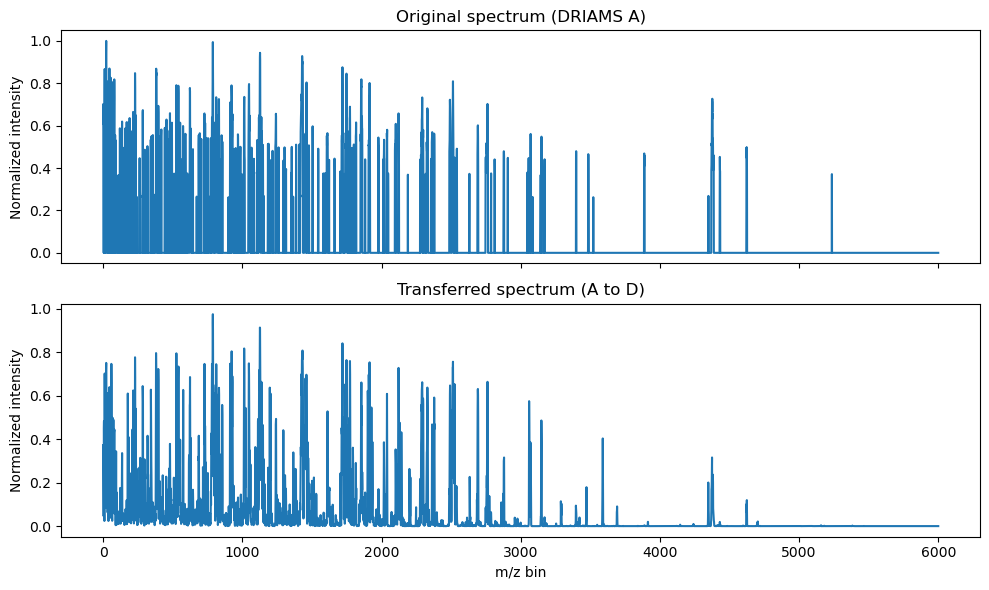

In [47]:
i = 0  # spectrum idx

mz = np.arange(dataA.shape[1])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Original A
axes[0].plot(mz, dataA[i])
axes[0].set_title("Original spectrum (DRIAMS A)")
axes[0].set_ylabel("Normalized intensity")

# A to D
axes[1].plot(mz, X_A_to_D[i])
axes[1].set_title("Transferred spectrum (A to D)")
axes[1].set_ylabel("Normalized intensity")
axes[1].set_xlabel("m/z bin")

plt.tight_layout()
plt.show()

#### Transfer D to A

In [27]:
X_D_to_A = style_transfer(
    model=vae,
    X=dataD,
    domain_target_id=DOMAIN_MAP["DRIAMS_A"],
    device=device
)

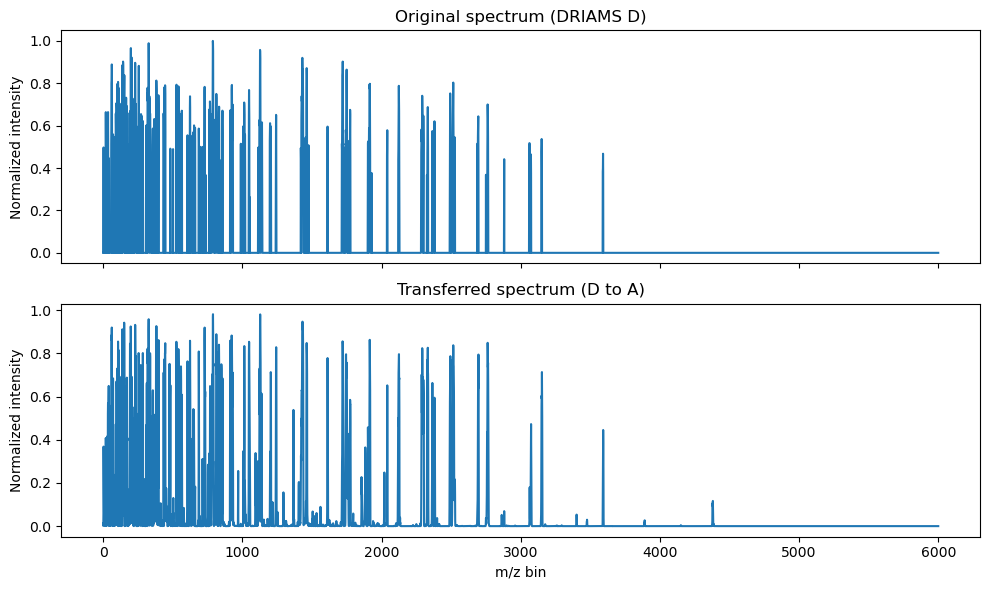

In [48]:
i = 0  # spectrum idx

mz = np.arange(dataD.shape[1])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Original D
axes[0].plot(mz, dataD[i])
axes[0].set_title("Original spectrum (DRIAMS D)")
axes[0].set_ylabel("Normalized intensity")

# D to A
axes[1].plot(mz, X_D_to_A[i])
axes[1].set_title("Transferred spectrum (D to A)")
axes[1].set_ylabel("Normalized intensity")
axes[1].set_xlabel("m/z bin")

plt.tight_layout()
plt.show()